#Predição de diagnósticos de leucemias por meio da análise de lâminas de sangue periférico

## Projeto de conclusão da pós-graduação em BI Master na PUC-Rio

Aluno: **Matheus Barbosa Gevaerd**

Matrícula: **222.100.023**

Orientadora: **Professora Manoela Kohler**

Este projeto utiliza duas bases de dados abertas ([subtypes_of_leukemia_blood_cell_microscopic_image](https://www.kaggle.com/datasets/sheikhlubna/subtypes-of-leukemia-blood-cell-microscopic-image?resource=download&select=acute_lymphocytic) e [leukemia_dataset](https://www.kaggle.com/datasets/priyaadharshinivs062/leukemia-dataset/data)) com imagens de lâminas de sangue periférico de leucemias e de pacientes saudáveis. Em conjunto, as bases possuem 18.000 imagens agrupadas em cinco diferentes grupos: Leucemia Linfóide Aguda (LLA), Leucemia Mieloide Aguda (LMA), Leucemia Linfocítica Crônica (LLC), Leucemia Mieloide Crônica (LMC) e Imagens de Pacientes Saudáveis (Normal).

## Objetivo

Desenvolver um modelo eficaz de deep learning para detecção de leucemias a partir de imagens de lâminas de sangue periférico. Para isso, pretende-se utilizar um modelo pré-treinado e por meio de transfer learning introduzir os parâmetros necessários para a correta identificação.

## Bibliotecas e Datasets

A primeira etapa do projeto compreende a importação dos datasets hospedados no kaggle para o ambiente interno do Google Colab. Dessa forma, pretende-se otimizar o armazenamento sem necessidade de acesso ao Google Drive.

In [ ]:
import kagglehub
leukemia_dataset_path = kagglehub.dataset_download('priyaadharshinivs062/leukemia-dataset')
subtypes_of_leukemia_blood_cell_microscopic_image_path = kagglehub.dataset_download('sheikhlubna/subtypes-of-leukemia-blood-cell-microscopic-image')

print('Datasets importados.')

100%|██████████| 22.3G/22.3G [20:59<00:00, 19.0MB/s]

Extracting files...


100%|██████████| 74.3M/74.3M [00:05<00:00, 14.2MB/s]

Extracting files...


Datasets importados.


In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

Neste momento as bibliotecas que serão utilizadas no projeto são importadas. Importante destacar que o projeto utiliza a rede convolucional MobileNetV2, escolhida pois temos um problema multiclasse e com imagens complexas de microscopia.

In [ ]:
import pandas as pd
import numpy as np
import keras
import warnings
warnings.filterwarnings(action="ignore")
import matplotlib.pyplot as plt
%matplotlib inline

from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

import sklearn.metrics as metrics
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
annealer = LearningRateScheduler(lambda x: 1e-3 * 0.95 ** x, verbose=0)

import cv2

## Dividir imagens de treino, teste e validação

É necessário, para a correta classificação das leucemias e indivíduos saudáveis, agrupar as duas bases de dados em três conjuntos: train, test e val.

Primeiro agrupamos as duas bases de acordo com a classificação das imagens.

In [ ]:
# Definindo os diretórios ajustados
LLA = [os.path.join(subtypes_of_leukemia_blood_cell_microscopic_image_path, 'acute_lymphocytic'),
      os.path.join(leukemia_dataset_path, 'train/train/all train/all train')]

LMA = [os.path.join(subtypes_of_leukemia_blood_cell_microscopic_image_path, 'acute_myelogenous'),
      os.path.join(leukemia_dataset_path, 'train/train/aml train/aml train')]

LLC = [os.path.join(subtypes_of_leukemia_blood_cell_microscopic_image_path, 'chronic_lymphocytic'),
      os.path.join(leukemia_dataset_path, 'train/train/cll train/cll train')]

LMC = [os.path.join(subtypes_of_leukemia_blood_cell_microscopic_image_path, 'chronic_myelogenous'),
      os.path.join(leukemia_dataset_path, 'train/train/cml/cml')]

Normal = [os.path.join(subtypes_of_leukemia_blood_cell_microscopic_image_path, 'healthy_blood_cell'),
     os.path.join(leukemia_dataset_path, 'train/train/h train/h train')]

Após, é preciso criar um dataframe para observar o correto balanceamento entre as classes de imagens.

In [ ]:
filepaths = []
labels = []
dict_lists = [LLA, LMA, LLC, LMC, Normal]
class_labels = ['LLA', 'LMA', 'LLC', 'LMC', 'Normal']

for i, dir_list in enumerate(dict_lists):
    for j in dir_list:
        flist = os.listdir(j)
        for f in flist:
            fpath = os.path.join(j, f)
            filepaths.append(fpath)
            labels.append(class_labels[i])

Fseries = pd.Series(filepaths, name="filepaths")
Lseries = pd.Series(labels, name="labels")
data = pd.concat([Fseries, Lseries], axis=1)
df = pd.DataFrame(data)
print(df.head())
print(df["labels"].value_counts())

                                           filepaths labels
0  /root/.cache/kagglehub/datasets/sheikhlubna/su...    LLA
1  /root/.cache/kagglehub/datasets/sheikhlubna/su...    LLA
2  /root/.cache/kagglehub/datasets/sheikhlubna/su...    LLA
3  /root/.cache/kagglehub/datasets/sheikhlubna/su...    LLA
4  /root/.cache/kagglehub/datasets/sheikhlubna/su...    LLA
labels
LLA       3600
LMA       3600
LLC       3600
LMC       3600
Normal    3600
Name: count, dtype: int64


 Há exatamente 3600 imagens em cada classe, demonstrando o correto balanceamento das duas bases abertas utilizadas.

In [ ]:
df.shape

(18000, 2)

Com o agrupamento das duas bases temos 18000 imagens, uma quantidade considerável para o correto treinamento e teste.

Dessa forma, é necessário dividir os registros nos três conjuntos de dados (train, test e val) com uma proporção de 20% para teste e 10% para validação.

In [ ]:
train_images, test_images = train_test_split(df, test_size=0.2)
train_set, val_set = train_test_split(train_images, test_size=0.1)

In [ ]:
print(train_set.shape)
print(test_images.shape)
print(val_set.shape)

train_counts = train_set['labels'].value_counts()
print(train_counts)

test_counts = test_images['labels'].value_counts()
print(test_counts)

val_counts = val_set['labels'].value_counts()
print(val_counts)

(12960, 2)
(3600, 2)
(1440, 2)
labels
Normal    2635
LLA       2598
LMC       2587
LMA       2570
LLC       2570
Name: count, dtype: int64
labels
LMA       738
LLC       732
LLA       724
LMC       718
Normal    688
Name: count, dtype: int64
labels
LLC       298
LMC       295
LMA       292
LLA       278
Normal    277
Name: count, dtype: int64


Após a divisão, os grupos seguem balanceados.

O próximo passo é transformar o dataframe em um repositório de imagens de acordo com as classes das imagens e os 3 conjuntos anteriormente separados. Para isso, utiliza-se os parâmetros mais adequados para a rede MobileNetV2.

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

image_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
train = image_gen.flow_from_dataframe(dataframe= train_set,x_col="filepaths",y_col="labels",
                                      target_size=(224,224),
                                      color_mode='rgb',
                                      class_mode="categorical",
                                      batch_size=32,
                                      shuffle=True
                                     )
test = image_gen.flow_from_dataframe(dataframe= test_images,x_col="filepaths", y_col="labels",
                                     target_size=(224,224),
                                     color_mode='rgb',
                                     class_mode="categorical",
                                     batch_size=32,
                                     shuffle= False
                                    )
val = image_gen.flow_from_dataframe(dataframe= val_set,x_col="filepaths", y_col="labels",
                                    target_size=(224,224),
                                    color_mode= 'rgb',
                                    class_mode="categorical",
                                    batch_size=32,
                                    shuffle=False
                                   )


train_save_path = 'train'
test_save_path = 'test'
val_save_path = 'val'

os.makedirs(train_save_path, exist_ok=True)
os.makedirs(test_save_path, exist_ok=True)
os.makedirs(val_save_path, exist_ok=True)

Found 12960 validated image filenames belonging to 5 classes.
Found 3600 validated image filenames belonging to 5 classes.
Found 1440 validated image filenames belonging to 5 classes.


A próxima etapa é alocar as imagens em suas respectivas pastas, permitindo o treinamento adequado futuramente.

In [ ]:
def save_images_from_generator(generator, save_path):
    total_batches = len(generator)
    for batch_num in range(total_batches):
        imgs, labels = next(generator)
        for i in range(imgs.shape[0]):
            img = tf.keras.preprocessing.image.array_to_img(imgs[i])
            label = generator.labels[generator.index_array[batch_num * generator.batch_size + i]]
            label_folder = os.path.join(save_path, str(label))
            os.makedirs(label_folder, exist_ok=True)
            img.save(os.path.join(label_folder, f"img_{batch_num * generator.batch_size + i}.png"))


save_images_from_generator(train, train_save_path)
save_images_from_generator(test, test_save_path)
save_images_from_generator(val, val_save_path)

print("imagens salvas")

imagens salvas


In [ ]:
classes=list(train.class_indices.keys())
print (classes)

['LLA', 'LLC', 'LMA', 'LMC', 'Normal']


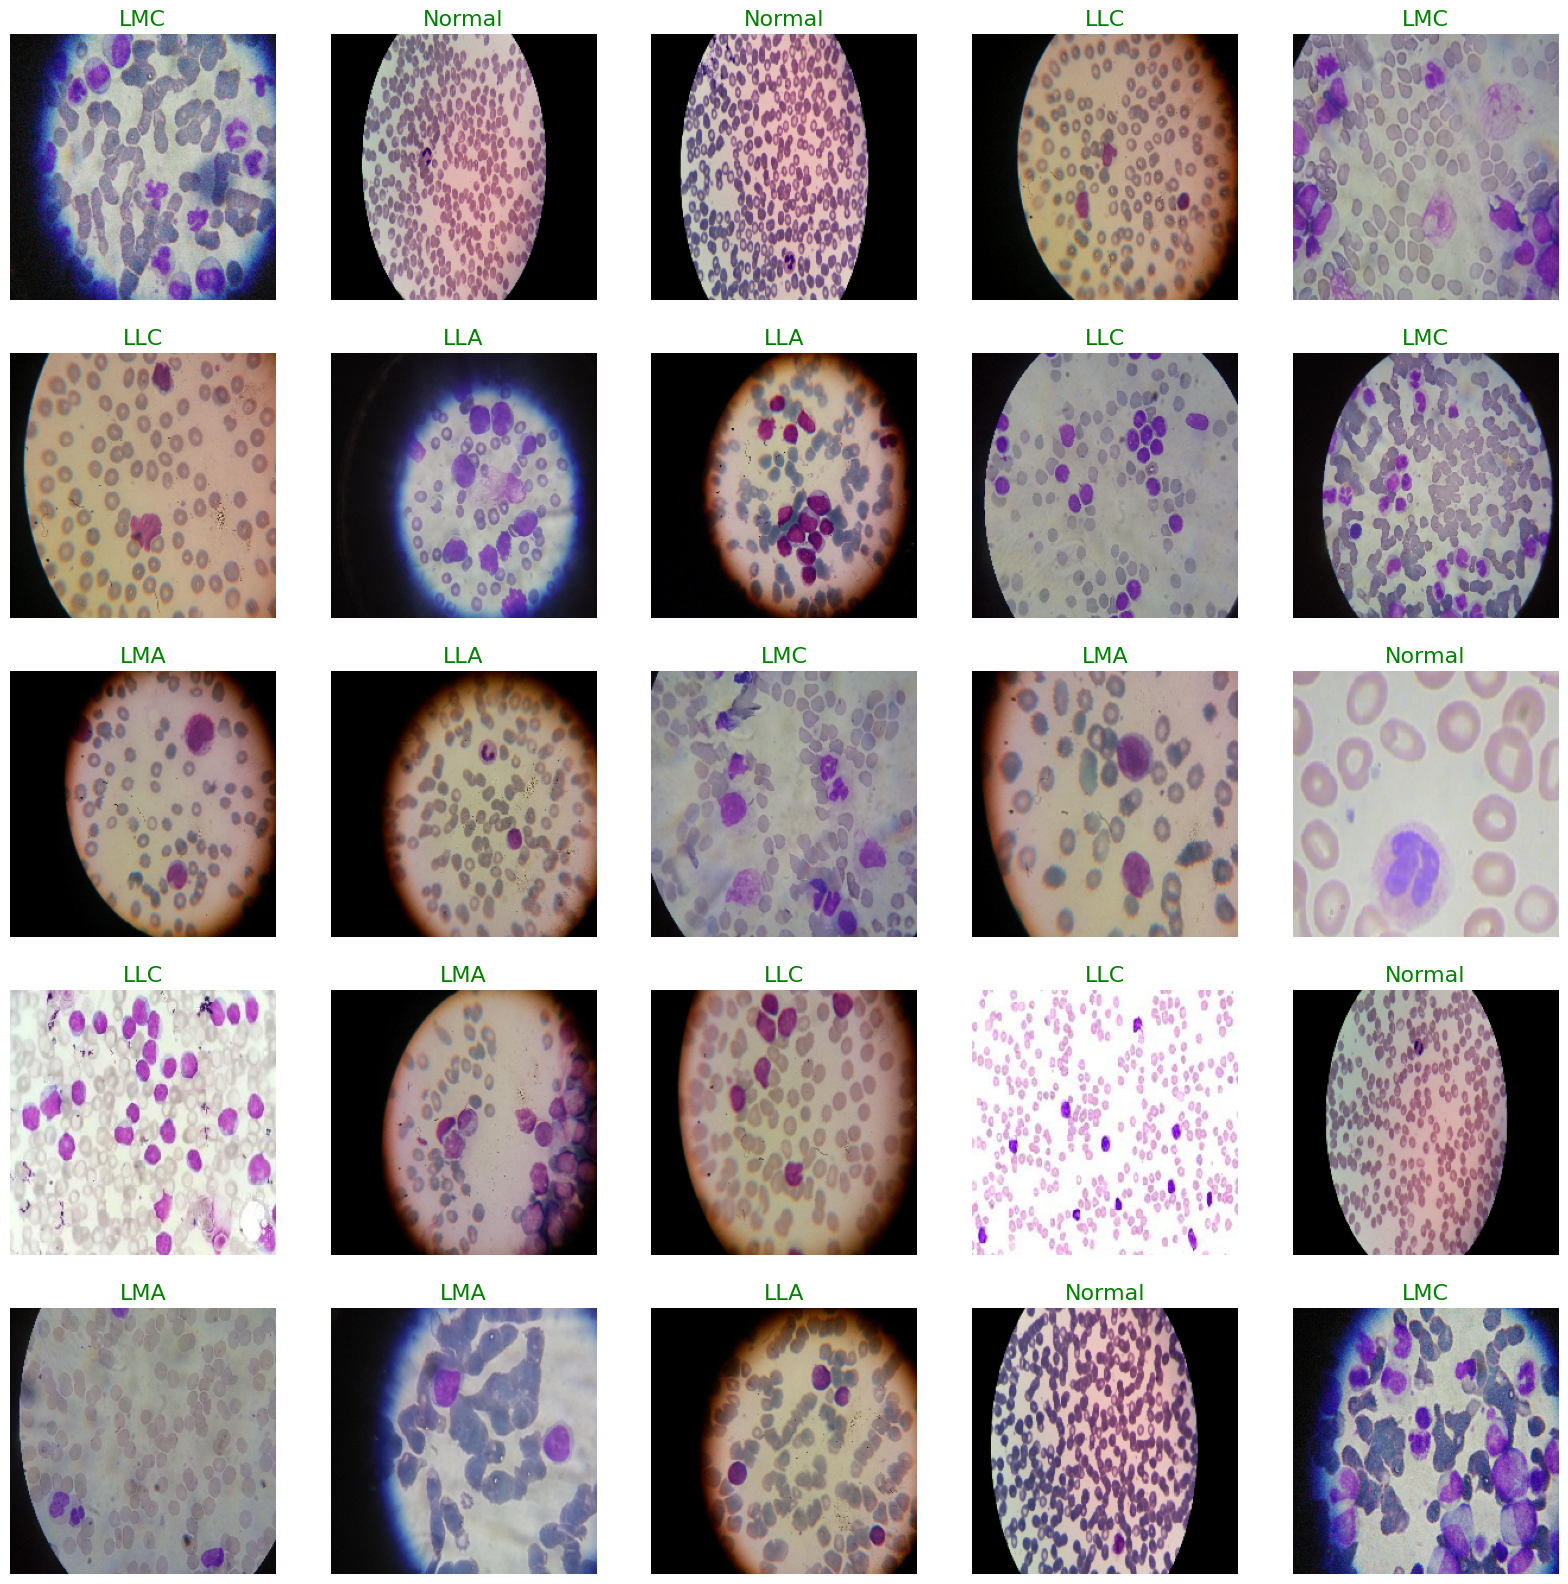

In [ ]:
def show_imagens_laminas(image_gen):
    test_dict = test.class_indices
    classes = list(test_dict.keys())
    images, labels=next(image_gen)
    plt.figure(figsize=(20,20))
    length = len(labels)
    if length<25:
        r=length
    else:
        r=25
    for i in range(r):
        plt.subplot(5,5,i+1)
        image=(images[i]+1)/2
        plt.imshow(image)
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name, color="green",fontsize=16)
        plt.axis('off')
    plt.show()
show_imagens_laminas(train)

Registros alocados em cada categoria. Importante identificar as nuances em cada classe para que o modelo seja corretamente treinado.

## Carregando modelo pré-treinado

In [ ]:
# Carregar o MobileNetV2 pré-treinado
base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Transfer Learning

In [ ]:
# Congelar as camadas do modelo base
base_model.trainable = False

In [ ]:
# Adicionar camadas customizadas no topo
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)  # Regularização
predictions = Dense(5, activation='softmax')(x)

In [ ]:
# Compilar o modelo
model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Resumo do modelo
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise_BN 

 Total params: 18,315,845 (69.87 MB)

 Trainable params: 16,057,861 (61.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Todas as camadas apresentadas acima, com o acréscimo das camadas personalizadas.

In [ ]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("predicao_leucemias.keras", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

history = model.fit(
    train,
    validation_data=val,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 883s 2s/step - accuracy: 0.8199 - loss: 0.6129 - val_accuracy: 0.9681 - val_loss: 0.0893 - learning_rate: 1.0000e-04
Epoch 2/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 802s 2s/step - accuracy: 0.9612 - loss: 0.1110 - val_accuracy: 0.9840 - val_loss: 0.0468 - learning_rate: 1.0000e-04
Epoch 3/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 809s 2s/step - accuracy: 0.9724 - loss: 0.0776 - val_accuracy: 0.9826 - val_loss: 0.0458 - learning_rate: 1.0000e-04
Epoch 4/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 805s 2s/step - accuracy: 0.9807 - loss: 0.0569 - val_accuracy: 0.9819 - val_loss: 0.0510 - learning_rate: 1.0000e-04
Epoch 5/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 800s 2s/step - accuracy: 0.9850 - loss: 0.0447 - val_accuracy: 0.9806 - val_loss: 0.0537 - learning_rate: 1.0000e-04
Epoch 6/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 791s 2s/step - accuracy: 0.9935 - loss: 0.0200 - val_accuracy: 0.9868 - val_loss: 0.0413 - learning_rate: 5.0000e-05
Epoch 7/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 787s 2s/step - acc

Treinamento realizado corretamente evitando overfitting com os callbacks, além de bons parâmetros de acurácia e perdas.

## Avaliação do modelo

Nesse momento, há a análise das métricas do modelo treinado. Avaliando o desempenho entre os conjuntos de treino e teste, buscando inconsistências e correta classificação.

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

def PlotHistory(history):
    print(history.history.keys())
    # Resume histórico por acurâcia
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()
    # Resume histórico por perdas
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()

In [ ]:
score = model.evaluate(val, verbose=0)
print("\nTest score:", score[0])
print('Test accuracy:', score[1])


Test score: 0.0369931235909462
Test accuracy: 0.9888888597488403


Conjunto de teste com boa acurácia e perdas aceitáveis, apesar de desempenho um pouco inferior ao conjunto de treino. Isso se justifica também pela quantidade de imagens em cada conjunto.

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


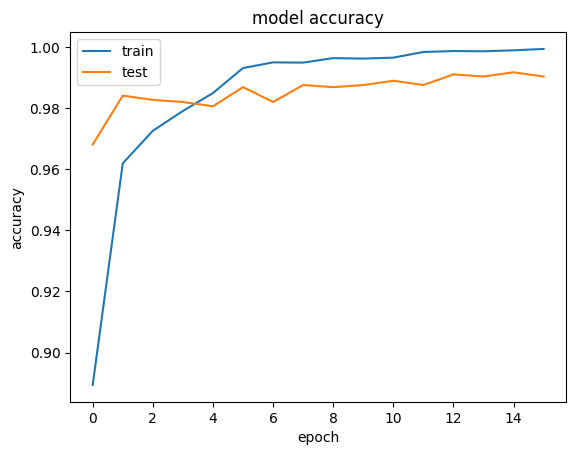

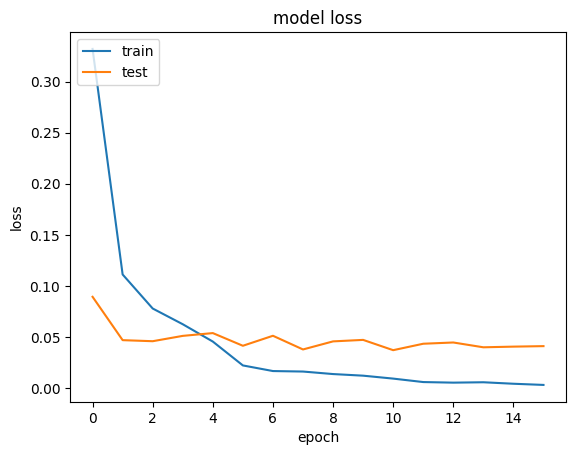

In [ ]:
PlotHistory(history)

Evidencia historicamente o correto treinamento do modelo e os resultados aceitáveis no conjunto de testes. Futuramente, com uma quantidade maior de registros no conjunto teste o resultado pode ser ainda mais similar ao conjunto de treino.

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Fazer as predições
predictions = model.predict(test)
y_pred = np.argmax(predictions, axis=1)
y_true = test.classes
class_labels = list(test.class_indices.keys())

113/113 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step


In [ ]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

Classification Report:
              precision    recall  f1-score   support

         LLA       0.99      1.00      0.99       724
         LLC       1.00      0.97      0.98       732
         LMA       0.98      0.99      0.98       738
         LMC       0.99      0.99      0.99       718
      Normal       1.00      1.00      1.00       688

    accuracy                           0.99      3600
   macro avg       0.99      0.99      0.99      3600
weighted avg       0.99      0.99      0.99      3600



Métricas individualizadas por categoria demonstram que o modelo é eficiente para identificar corretamente as categorias. Além disso, tem 100% de precisão em diferenciar indivíduos saudáveis de indíviduos com células atípicas, um dos objetivos do modelo.

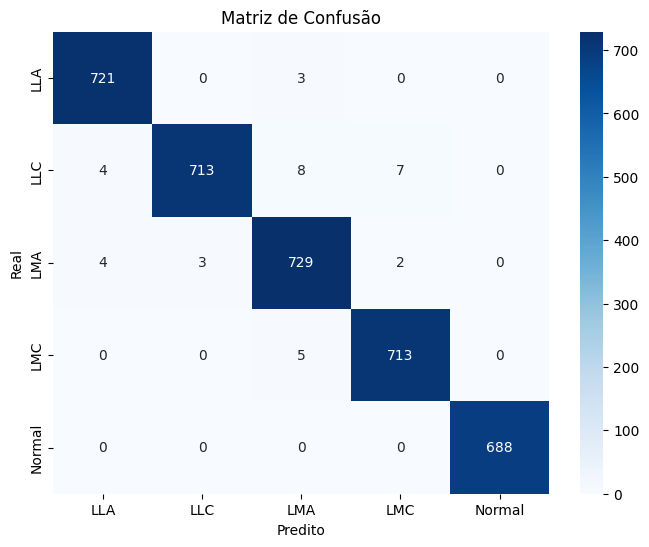

In [ ]:
# Matriz de confusão
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()


Na matriz de confusão é possível destacar a precisão na categoria de indivíduos saudáveis e a baixa confusão no momento de classificação do modelo de maneira geral.

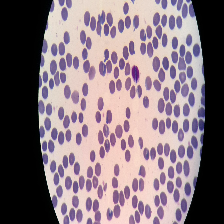

In [ ]:
from tensorflow.keras.preprocessing.image import load_img

# Carregar a imagem e redimensionar para 224x224
imagem = load_img('/content/test/4/img_100.png', target_size=(224, 224))

# Exibir a imagem carregada
imagem


In [ ]:
imagem=np.array(imagem)


cls  = model.predict(imagem[np.newaxis,:,:,:]/255.)
print(cls)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[[2.9949580e-25 6.9039942e-19 1.3291725e-24 6.9504921e-22 1.0000000e+00]]


Teste do modelo com uma imagem de células normais aponta a classificação na categoria correta pela predição do modelo. Posteriormente será analisado pelo GRAD-CAM.

## Grad-CAM

O Grad-CAM é uma ferramenta importante nesse caso pois indica quais partes da imagem estão sendo determinantes para a categorização. Dessa forma, os especialistas na área podem confirmar a correta análise do modelo e o que está sendo analisado na imagem da lâmina de sangue periférico.

In [ ]:
# Função para calcular o Grad-CAM
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Obter as ativações e o gradiente da camada convolucional escolhida
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Gradiente em relação às ativações da última camada convolucional
    grads = tape.gradient(class_channel, conv_outputs)

    # Média global ponderada para obter a importância de cada canal
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    # Pesos multiplicados pelas ativações
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    # Normalizar entre 0 e 1
    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap

In [ ]:
# Função para exibir o Grad-CAM sobre a imagem
def display_gradcam(image_input, model, last_conv_layer_name, class_labels):

    if isinstance(image_input, str):
        img = load_img(image_input, target_size=(224, 224))  # Carregar imagem
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)  # Pré-processamento
    elif isinstance(image_input, np.ndarray):
        if image_input.ndim == 3:
            img_array = np.expand_dims(image_input, axis=0)
        else:
            img_array = image_input
        img = tf.keras.utils.array_to_img(image_input)  # Converter de volta para imagem para exibição
    else:
        raise TypeError("image_input deve ser um caminho (string) ou um array numpy!")

    # Criar o mapa de calor usando Grad-CAM
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    # Adicionar uma dimensão ao mapa de calor para compatibilidade com tf.image.resize
    heatmap = np.expand_dims(heatmap, axis=-1)

    # Redimensionar o mapa de calor para o tamanho da imagem original
    heatmap_resized = tf.image.resize(heatmap, (224, 224)).numpy()

    # Normalizar o heatmap para valores entre 0 e 255
    heatmap_resized = np.squeeze(heatmap_resized)  # Remover dimensão extra
    heatmap_resized = (heatmap_resized * 255).astype("uint8")

    # Plotar a imagem original e o Grad-CAM
    plt.figure(figsize=(10, 10))

    # Imagem original
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Imagem Original')

    # Imagem com Grad-CAM sobreposta
    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.imshow(heatmap_resized, cmap='jet', alpha=0.4)  # Sobreposição
    plt.axis('off')
    predicted_label = class_labels[tf.argmax(model.predict(img_array)[0])]
    plt.title(f"Grad-CAM - Classe Prevista: {predicted_label}")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


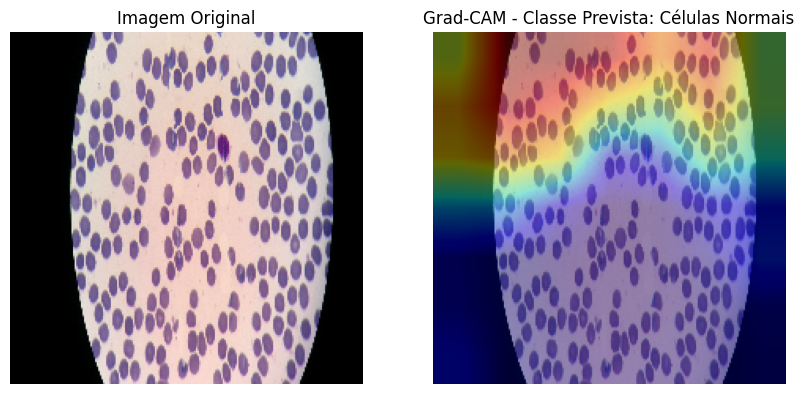

In [ ]:
# Configurações
last_conv_layer_name = 'Conv_1'
class_labels = ['LLA', 'LMA', 'LLC', 'LMC', 'Células Normais']

# Avaliar o modelo em uma imagem
image_path = '/content/test/4/img_100.png'  # Caminho da imagem
display_gradcam(image_path, model, last_conv_layer_name, class_labels)

A análise do Grad-CAM aponta a correta classificação da imagem, destacando em vermelho os pontos principais para a indicação da categoria.

##Conclusão e trabalhos futuros

O modelo de predição de diagnósticos de leucemias por meio da análise de lâminas de sangue periférico com um conjunto de dados totais de 18.000 imagens apresenta resultados satisfatórios: 98,8% de acurácia e 3,6% de perdas no conjunto teste, 99,9% de acurácia e 0,3% de perdas no conjunto de treinamento, 99% de acurácia e 4,1% de perdas no conjunto de validação.

Em relação aos dados específicos de cada categoria, o modelo testado apresentou 100% de precisão na identificação de lâminas com células normais, conforme relatório abaixo:

    Classes    precision    recall   f1-score   support

         LLA       0.99      1.00      0.99       724
         LLC       1.00      0.97      0.98       732
         LMA       0.98      0.99      0.98       738
         LMC       0.99      0.99      0.99       718
      Normal       1.00      1.00      1.00       688

    accuracy                           0.99      3600
    macro avg      0.99      0.99      0.99      3600
    weighted avg   0.99      0.99      0.99      3600

Importante destacar que o conjunto teste teve menos de 1.000 imagens por categoria, tendo um resultado satisfatório sem uma quantidade grande de imagens.

Trabalhos futuros podem utilizar o modelo em um conjunto de dados de diferentes tamanhos, além de estimar a capacidade de inferência para outras patologias hematológicas (anemias, síndromes mieloproliferativas, distúrbios dos plasmócitos e/ou alterações plaquetárias). Seria possível também subdividir o treinamento com imagens de diferentes aumentos e técnicas de coloração de lâminas (Panótico Rápido e a coloração Giemsa).

## Referências



*   [Abhishek, A., Jha, R. K., Sinha, R., & Jha, K. (2023). Automated detection and classification of leukemia on a subject-independent test dataset using deep transfer learning supported by Grad-CAM visualization. Biomedical Signal Processing and Control, 83, 104722.](https://https://www.sciencedirect.com/science/article/pii/S1746809423001556#da1)
*   [Alsalem, M. A., Zaidan, A. A., Zaidan, B. B., Hashim, M., Madhloom, H. T., Azeez, N. D., & Alsyisuf, S. (2018). A review of the automated detection and classification of acute leukaemia: Coherent taxonomy, datasets, validation and performance measurements, motivation, open challenges and recommendations. Computer methods and programs in biomedicine, 158, 93-112.](https://https://www.sciencedirect.com/science/article/abs/pii/S0169260717314761)





---


Matrícula: 222.100.023

Pontifícia Universidade Católica do Rio de Janeiro

Curso de Pós Graduação Business Intelligence Master



